In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


FF++ clean test set

In [2]:
!cp -r /content/drive/MyDrive/DL_Project/datasets/ffpp_cropped_faces/test /content/

In [3]:
!mv /content/test /content/ffpp_test

CelebV2 clean set

In [4]:
!cp -r /content/drive/MyDrive/DL_Project/datasets/celebv2_cropped_faces /content/

Compressed Dataset

In [5]:
!cp /content/drive/MyDrive/DL_Project/datasets/compressed_ffpp_celebv2.zip /content/

In [6]:
!unzip -q /content/compressed_ffpp_celebv2.zip -d /content/

Dependencies and Imports...

In [7]:
!pip install -q timm torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.5 MB/s eta 0:00:00


In [8]:
import timm

import os
import random
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [24]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='torch.utils.data.dataloader')

Rrproducibility...

In [25]:
seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


Datasets...

In [27]:
class DeepfakeDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.transform = transform
        self.samples = []

        real_dir = os.path.join(root_dir, 'real')
        fake_dir = os.path.join(root_dir, 'fake')

        for img in os.listdir(real_dir):
            self.samples.append((os.path.join(real_dir, img), 0))

        for img in os.listdir(fake_dir):
            self.samples.append((os.path.join(fake_dir, img), 1))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [28]:
DATASETS = {
    # ff++..
    'ffpp_clean':
        '/content/ffpp_test',

    'ffpp_q90':
        '/content/compressed_ffpp_celebv2/ffpp/q90',

    'ffpp_q70':
        '/content/compressed_ffpp_celebv2/ffpp/q70',

    'ffpp_q50':
        '/content/compressed_ffpp_celebv2/ffpp/q50',

    'ffpp_q30':
        '/content/compressed_ffpp_celebv2/ffpp/q30',

    'ffpp_q10':
        '/content/compressed_ffpp_celebv2/ffpp/q10',

    # celebv2...
    'celebv2_clean':
        '/content/celebv2_cropped_faces',

    'celebv2_q90':
        '/content/compressed_ffpp_celebv2/celebv2/q90',

    'celebv2_q70':
        '/content/compressed_ffpp_celebv2/celebv2/q70',

    'celebv2_q50':
        '/content/compressed_ffpp_celebv2/celebv2/q50',

    'celebv2_q30':
        '/content/compressed_ffpp_celebv2/celebv2/q30',

    'celebv2_q10':
        '/content/compressed_ffpp_celebv2/celebv2/q10',
}

In [29]:
for name, path in DATASETS.items():

    real_count = len(os.listdir(os.path.join(path, 'real')))

    fake_count = len(os.listdir(os.path.join(path, 'fake')))

    print(f'{name:15s} | '
    f'real={real_count:4d} | '
    f'fake={fake_count:4d} | '
    f'total={real_count+fake_count:4d}')

ffpp_clean      | real=1250 | fake=1138 | total=2388
ffpp_q90        | real=1250 | fake=1138 | total=2388
ffpp_q70        | real=1250 | fake=1138 | total=2388
ffpp_q50        | real=1250 | fake=1138 | total=2388
ffpp_q30        | real=1250 | fake=1138 | total=2388
ffpp_q10        | real=1250 | fake=1138 | total=2388
celebv2_clean   | real=2999 | fake=2991 | total=5990
celebv2_q90     | real=2999 | fake=2991 | total=5990
celebv2_q70     | real=2999 | fake=2991 | total=5990
celebv2_q50     | real=2999 | fake=2991 | total=5990
celebv2_q30     | real=2999 | fake=2991 | total=5990
celebv2_q10     | real=2999 | fake=2991 | total=5990


Evaluation Function...

In [30]:
@torch.no_grad()

def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_probs = []
    all_preds = []

    for images, labels in tqdm(loader, leave=False):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).squeeze(1)
        labels = labels.float().view_as(outputs)

        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    auc = roc_auc_score(all_labels, all_probs)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return {
        'loss': epoch_loss,
        'auc': auc,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'labels': np.array(all_labels),
        'probs': np.array(all_probs),
        'preds': np.array(all_preds)
    }

Transforms and Loss Function...

In [31]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# xception...

xception_transform = transforms.Compose([transforms.Resize((299,299)), transforms.ToTensor(),
                                         transforms.Normalize(imagenet_mean, imagenet_std)])

In [32]:
criterion = nn.BCEWithLogitsLoss()

Model Loading and Generic Evaluation Engine...

In [33]:
def load_model():

    model = timm.create_model('xception65', pretrained=False, num_classes=1)

    checkpoint_path = ('/content/drive/MyDrive/DL_Project/checkpoints/best_cat_xception.pth')

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    model.load_state_dict(checkpoint['model_state_dict'])

    model = model.to(device)
    model.eval()

    print(
        f'\nCompression-Aware Xception65 loaded '
        f'(best validation AUC = {checkpoint["best_auc"]:.4f})'
    )

    return model

In [34]:
def evaluate_all_datasets(model, transform, model_name):

    results = []
    stored_metrics = {}

    for dataset_name, dataset_path in DATASETS.items():

        print(f'\n{model_name.upper()} | '
        f'{dataset_name}')

        dataset = DeepfakeDataset(dataset_path, transform=transform)

        loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2, persistent_workers=True, pin_memory=True)

        metrics = evaluate(model, loader, criterion)

        stored_metrics[dataset_name] = metrics

        if 'ffpp' in dataset_name:
            dataset_type = 'FF++'

        else:
            dataset_type = 'CelebV2'

        quality = dataset_name.split('_')[-1]

        results.append({
            'Model':
                model_name,
            'Dataset':
                dataset_type,
            'Quality':
                quality,

            'AUC':
                metrics['auc'],

            'Accuracy':
                metrics['accuracy'],
            'Precision':
                metrics['precision'],
            'Recall':
                metrics['recall'],
            'F1':
                metrics['f1']
        })

        print(f'\nAUC={metrics['auc']:.4f} | '
        f'ACC={metrics['accuracy']:.4f} | '
        f'F1={metrics['f1']:.4f}')

    results_df = pd.DataFrame(results)

    return (results_df, stored_metrics)

In [35]:
cat_model = load_model()


Compression-Aware Xception65 loaded (best validation AUC = 0.9593)


Evaluations...

In [36]:
OUTPUT_DIR = '/content/drive/MyDrive/DL_Project/results/cat_xception_compression_results'

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [37]:
cat_model = load_model()
cat_results_df, cat_metrics = (evaluate_all_datasets(cat_model, xception_transform,'CAT-Xception'))

cat_csv = os.path.join(OUTPUT_DIR,'cat_xception_compression_results.csv')
cat_results_df.to_csv(cat_csv, index=False)

print(f'\nsaved: {cat_csv}')
display(cat_results_df)


Compression-Aware Xception65 loaded (best validation AUC = 0.9593)

CAT-XCEPTION | ffpp_clean


  0%|          | 0/75 [00:00<?, ?it/s]


AUC=0.9452 | ACC=0.8777 | F1=0.8708

CAT-XCEPTION | ffpp_q90


  0%|          | 0/75 [00:10<?, ?it/s]


AUC=0.9289 | ACC=0.8681 | F1=0.8598

CAT-XCEPTION | ffpp_q70


...

  0%|          | 0/188 [00:00<?, ?it/s]


AUC=0.7606 | ACC=0.6975 | F1=0.7127

CAT-XCEPTION | celebv2_q10


  0%|          | 0/188 [00:00<?, ?it/s]


AUC=0.6838 | ACC=0.6025 | F1=0.4789

saved: /content/drive/MyDrive/DL_Project/results/cat_xception_compression_results/cat_xception_compression_results.csv


,Model,Dataset,Quality,AUC,Accuracy,Precision,Recall,F1
0,CAT-Xception,FF++,clean,0.945185,0.877722,0.877005,0.864675,0.870796
1,CAT-Xception,FF++,q90,0.928906,0.868090,0.871055,0.848858,0.859813
2,CAT-Xception,FF++,q70,0.943585,0.862228,0.877684,0.826011,0.851064
3,CAT-Xception,FF++,q50,0.924500,0.834171,0.883264,0.751318,0.811966
4,CAT-Xception,FF++,q30,0.894164,0.776382,0.878446,0.615993,0.724174
5,CAT-Xception,FF++,q10,0.783762,0.667923,0.827324,0.383128,0.523724
6,CAT-Xception,CelebV2,clean,0.803947,0.676962,0.614286,0.948847,0.745763
7,CAT-Xception,CelebV2,q90,0.800712,0.673623,0.611879,0.947175,0.743472
8,CAT-Xception,CelebV2,q70,0.797261,0.700000,0.639226,0.916416,0.753125
9,CAT-Xception,CelebV2,q50,0.785286,0.712521,0.661904,0.867268,0.750796


Compression Robustness Plots...

In [38]:
QUALITY_ORDER = [
    'clean',
    'q90',
    'q70',
    'q50',
    'q30',
    'q10'
]

def plot_single_curve(df, model_name, dataset_name, save_name):

    subset = df[(df['Model'] == model_name) & (df['Dataset'] == dataset_name)].copy()
    subset['Quality'] = pd.Categorical(subset['Quality'], categories=QUALITY_ORDER, ordered=True)
    subset = subset.sort_values('Quality')

    plt.figure(figsize=(8,5))

    plt.plot(subset['Quality'], subset['AUC'], marker='o')
    plt.title(f'{model_name} - {dataset_name}')
    plt.xlabel('JPEG Quality')
    plt.ylabel('AUC')

    plt.grid(True)

    save_path = os.path.join(OUTPUT_DIR, save_name)
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print(f'\nsaved: {save_path}')

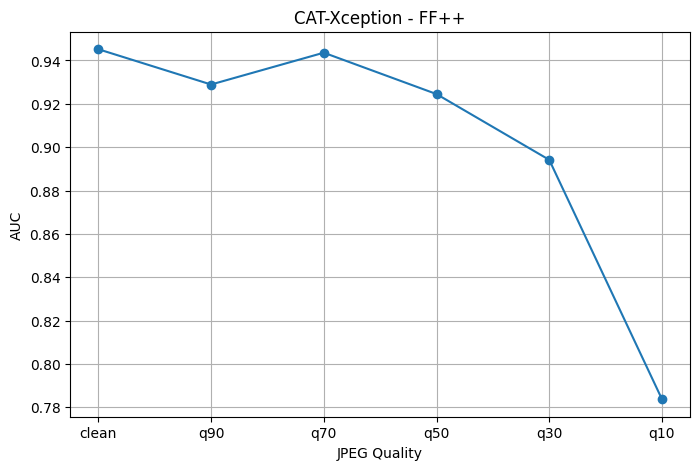


saved: /content/drive/MyDrive/DL_Project/results/cat_xception_compression_results/cat_xception65_ffpp_compression_auc.pdf


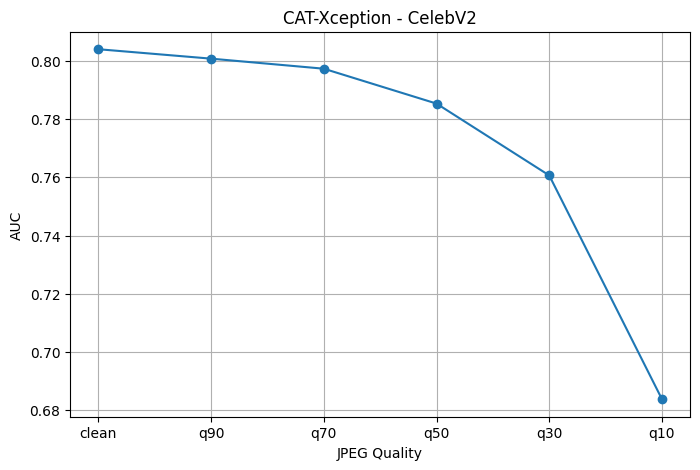


saved: /content/drive/MyDrive/DL_Project/results/cat_xception_compression_results/cat_xception65_celebv2_compression_auc.pdf


In [39]:
plot_single_curve(cat_results_df, 'CAT-Xception', 'FF++', 'cat_xception65_ffpp_compression_auc.pdf')

plot_single_curve(cat_results_df, 'CAT-Xception', 'CelebV2','cat_xception65_celebv2_compression_auc.pdf')

Confusion Matrices...

In [40]:
def save_confusion_matrix(metrics, dataset_name, model_name):

    labels = metrics['labels']
    preds = metrics['preds']

    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f'{model_name} - {dataset_name}')

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    save_path = os.path.join(OUTPUT_DIR, f'{model_name.lower()}_{dataset_name}_confusion_matrix.pdf')
    plt.savefig(save_path, bbox_inches='tight')

    plt.show()

    print(f'\nsaved: {save_path}')

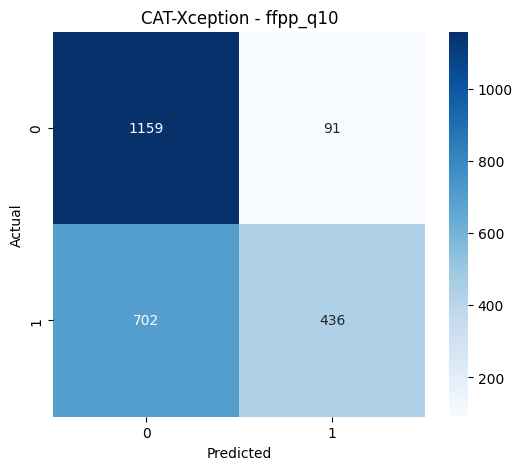


saved: /content/drive/MyDrive/DL_Project/results/cat_xception_compression_results/cat-xception_ffpp_q10_confusion_matrix.pdf


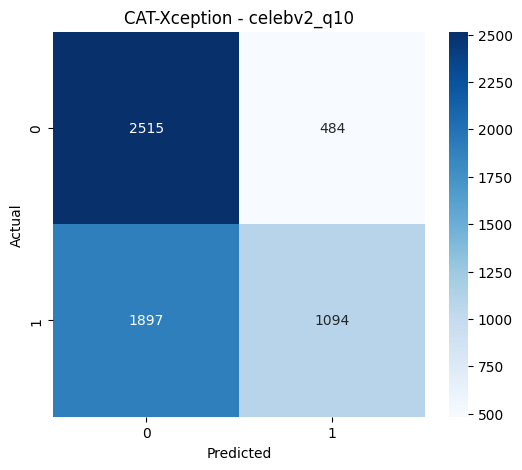


saved: /content/drive/MyDrive/DL_Project/results/cat_xception_compression_results/cat-xception_celebv2_q10_confusion_matrix.pdf


In [41]:
save_confusion_matrix(cat_metrics['ffpp_q10'], 'ffpp_q10', 'CAT-Xception')

save_confusion_matrix(cat_metrics['celebv2_q10'], 'celebv2_q10', 'CAT-Xception')